<a href="https://colab.research.google.com/github/srinivasveeru/Training/blob/main/HousePricePred3DModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Python program to draw a 3D plot that visualizes the regression model
#for house price prediction using suitable Python-based 3D plotting libraries

#Assume the following features were used:
# •	Area (sq ft)
# •	Number of Bedrooms
# •	House Price

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import cm

df = pd.read_csv('house_price_linear_regression.csv')

#print dataframe details
#df.info()
#df.head()
#df.describe()

#identify if there are any nulls in the data
#nullinfo = df.isnull().sum()
#print(nullinfo)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


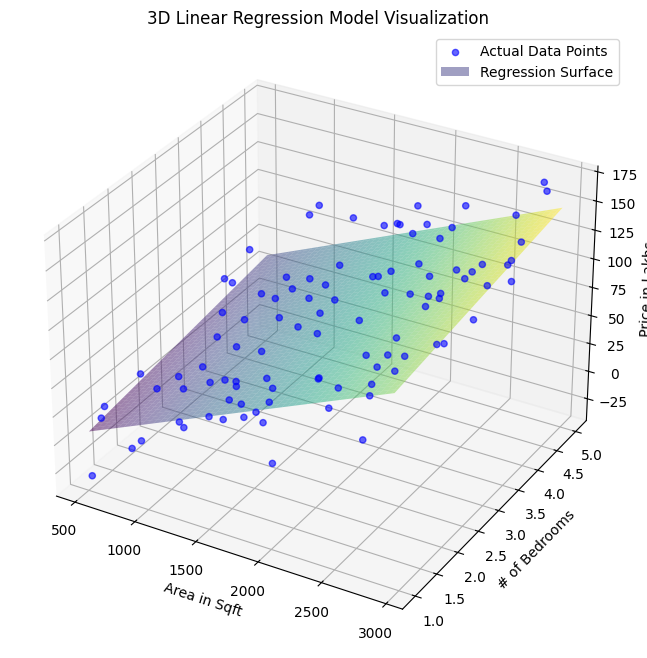

In [2]:
#Consider features of Area and Number of Bedrooms and target as house price in lakhs

X = df[['Area_sqft', 'Bedrooms']]
y = df['Price_lakhs']

#print(X,y)

model = LinearRegression()
model.fit(X, y)

# meshgrid for plotting the regression surface
Area_pred = np.linspace(X['Area_sqft'].min(), X['Area_sqft'].max(), 100)
Bedrooms_pred = np.linspace(X['Bedrooms'].min(), X['Bedrooms'].max(), 100)
X1_pred, X2_pred = np.meshgrid(Area_pred, Bedrooms_pred)

# Predict Z values (price in lakhs) for the entire meshgrid
Z_pred = model.predict(np.column_stack((X1_pred.flatten(), X2_pred.flatten())))
Z_pred = Z_pred.reshape(X1_pred.shape) # Reshape back to the grid structure

# Create a figure and a 3D subplot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the original data points
ax.scatter(X['Area_sqft'], X['Bedrooms'], y, color='blue', label='Actual Data Points', alpha=0.6)

# Plot the regression surface
ax.plot_surface(X1_pred, X2_pred, Z_pred, cmap=cm.viridis, alpha=0.5, label='Regression Surface')

# Set labels and title
ax.set_xlabel('Area in Sqft')
ax.set_ylabel('# of Bedrooms')
ax.set_zlabel('Price in Lakhs')
ax.set_title('3D Linear Regression Model Visualization')

# Add a legend
ax.legend()

# Display the plot
plt.show()
